# Isolate the split-leak fix from the encoder swap / hyperparameter shrink

`gaae-downstream-leakage-investigation.md` documents that the before/after GELSTM AUC
drop (0.967 -> 0.807) is **confounded**: three things changed at once between the two
runs — (1) the GAAE encoder was swapped/retrained (`bright-disco-4` -> `ethereal-planet-16`),
(2) a real val-side split leak was fixed (69/106 GEC-val subjects had been in GAAE-train),
and (3) the downstream LSTM's capacity/regularization shrank (`lstm_hidden` 128->32,
`lstm_layers` 2->1, `classifier_hidden` 64->32, plus added `standardize_features`/
`weight_decay`). The doc explicitly says isolating the leak's own contribution would
require a controlled rerun.

This notebook runs that controlled experiment: **same `bright-disco-4` GAAE encoder +
same old GELSTM hyperparameters as "before"**, but trained/evaluated on the **current
(leak-fixed) split**. If the resulting AUC stays close to 0.94-0.97 ("before"), the
split fix wasn't the main driver of the drop — the encoder swap / hyperparameter
shrink is. If it falls toward 0.80 ("after"), the leak was materially inflating the
"before" number.

A fresh training run is required here (not just re-evaluation) because train/val/test
subject membership changed between the legacy and current splits — there is no
existing checkpoint for "old encoder + old hyperparameters + new split".

In [1]:
import json
import sys
import types
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

HERE = Path.cwd()
REPO_ROOT = HERE.parents[2] if (HERE / "run_summaries").exists() else HERE
SRC = REPO_ROOT / "DOCS" / "seventh-meeting-tasks" / "src" if not (HERE / "run_summaries").exists() else HERE
CLASSIFIER_ROOT = REPO_ROOT / "CLASSIFIER"
for p in (str(REPO_ROOT), str(CLASSIFIER_ROOT)):
    if p not in sys.path:
        sys.path.insert(0, p)
print("Repo root:", REPO_ROOT)
print("Artifacts:", SRC)

Repo root: /mnt/e/fyassine/ad-early-detection
Artifacts: /mnt/e/fyassine/ad-early-detection/DOCS/seventh-meeting-tasks/src


In [2]:
from SHARED.seeding import set_seed, make_rng, make_torch_generator

SEED = 42
set_seed(SEED)
rng = make_rng(SEED)
torch_gen = make_torch_generator(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [3]:
WB_DATA_ROOT = str(REPO_ROOT / "DATA" / "DELCODE" / "__fc_wholebrain_sch200_flat__" / "matrices")
METADATA_DIR = REPO_ROOT / "DATA" / "DELCODE" / "__fc_wholebrain_sch200_flat__" / "metadata"
COHORTS_CSV = str(METADATA_DIR / "cohorts_with_scans_on_disk.csv")
CURRENT_SPLITS_DIR = REPO_ROOT / "DATA" / "DELCODE" / "__metadata__" / "SPLITS" / "downstream"

BEFORE = json.load(open(SRC / "run_summaries" / "before.json"))
AFTER = json.load(open(SRC / "run_summaries" / "after.json"))
print("'before' (old encoder + old config + LEAKY split):    test_auc =", BEFORE["test_auc"])
print("'after'  (new encoder + new config + FIXED split):    test_auc =", AFTER["test_auc"])

'before' (old encoder + old config + LEAKY split):    test_auc = 0.9666666666666668
'after'  (new encoder + new config + FIXED split):    test_auc = 0.8071428571428572


## 1. Extract `bright-disco-4` (the "before" GAAE encoder) — no standalone file exists

Confirmed by repo-wide search: `bright-disco-4` was never persisted as its own
checkpoint file. The only place its weights survive is bundled inside
`checkpoints/before/model_gelstm_2026-05-20_09-54-16.pth`, under the `encoder.*` key
prefix (`GELSTMClassifier.encoder` *is* the GAAE encoder — see
`old_gelstm/model/GELSTM/models.py`). Extracting once and caching to disk.

In [4]:
EXTRACTED_DIR = SRC / "checkpoints" / "bright-disco-4_extracted"
EXTRACTED_DIR.mkdir(parents=True, exist_ok=True)
EXTRACTED_ENCODER_PATH = EXTRACTED_DIR / "encoder_state_dict.pth"

if not EXTRACTED_ENCODER_PATH.exists():
    before_ckpt = torch.load(SRC / "checkpoints" / "before" / "model_gelstm_2026-05-20_09-54-16.pth",
                             map_location="cpu", weights_only=False)
    before_state = before_ckpt.get("model_state_dict", before_ckpt) if isinstance(before_ckpt, dict) else before_ckpt
    encoder_state = {k[len("encoder."):]: v for k, v in before_state.items() if k.startswith("encoder.")}
    torch.save(encoder_state, EXTRACTED_ENCODER_PATH)
    print(f"Extracted {len(encoder_state)} encoder tensors -> {EXTRACTED_ENCODER_PATH}")
else:
    print(f"Reusing previously extracted encoder: {EXTRACTED_ENCODER_PATH}")

Extracted 76 encoder tensors -> /mnt/e/fyassine/ad-early-detection/DOCS/seventh-meeting-tasks/src/checkpoints/bright-disco-4_extracted/encoder_state_dict.pth


## 2. Build the old-style train config + GAAE architecture dict

Values read straight off the frozen `old_gelstm/GELSTM_DELCODE_WHOLE_BRAIN.ipynb`
globals (also byte-identical to `run_summaries/before.json["hyperparams"]` where that
file has a field). `standardize_features=False` / `weight_decay=0.0` because the old
model has no `set_feature_norm` / the old training loop used plain Adam with no
weight decay — these fields didn't exist in the pre-adapter code, they are not being
"turned off" so much as never having existed. `gaae_hidden=200`: the old notebook sets
`GAAE_HIDDEN = IN_FEATURES` (200), not 128 like the *after*-run's encoder — confirmed
both from that cell and from the extracted checkpoint's own tensor shapes.

In [5]:
GAAE_HP_OLD = {
    "hidden_dim": 200,  # GAAE_HIDDEN = IN_FEATURES in the old notebook; NOT 128
    "latent_dim": 64, "num_heads": 2, "cond_dim": 2, "dropout": 0.3,
    "adjacency_k": 8, "file_variant": "z_transformed",
}

TRAIN_CONFIG_OLD = {
    "lstm_hidden": 128, "lstm_layers": 2, "lstm_dropout": 0.3, "classifier_hidden": 64,
    "use_time_delta": True, "graph_pool": "mean", "freeze_encoder": True,
    "standardize_features": False,  # didn't exist in the pre-adapter code
    "learning_rate": 0.001, "weight_decay": 0.0,  # plain Adam, no weight decay
    "epochs": 50, "early_stopping_patience": 15, "batch_size": 16,
    "use_class_cost_weights": True,  # old code's USE_CLASS_COST_WEIGHTS = True
    "grad_clip": 1.0, "n_folds": 5,
}
print("GAAE arch:  ", GAAE_HP_OLD)
print("Train config:", TRAIN_CONFIG_OLD)

GAAE arch:   {'hidden_dim': 200, 'latent_dim': 64, 'num_heads': 2, 'cond_dim': 2, 'dropout': 0.3, 'adjacency_k': 8, 'file_variant': 'z_transformed'}
Train config: {'lstm_hidden': 128, 'lstm_layers': 2, 'lstm_dropout': 0.3, 'classifier_hidden': 64, 'use_time_delta': True, 'graph_pool': 'mean', 'freeze_encoder': True, 'standardize_features': False, 'learning_rate': 0.001, 'weight_decay': 0.0, 'epochs': 50, 'early_stopping_patience': 15, 'batch_size': 16, 'use_class_cost_weights': True, 'grad_clip': 1.0, 'n_folds': 5}


## 3. Instantiate the live `GELSTMAdapter` with the old encoder + old config

In [6]:
from CLASSIFIER.adapters.gelstm import GELSTMAdapter

adapter = GELSTMAdapter(
    gaae_ckpt_path=str(EXTRACTED_ENCODER_PATH), gaae_hp=GAAE_HP_OLD, train_config=TRAIN_CONFIG_OLD,
    data_root=WB_DATA_ROOT, cohorts_csv=COHORTS_CSV, device=device, rng=rng,
)
_ = adapter.build_model()   # smoke-test arch construction + encoder load

[GAAE load] Loaded 76 parameters from /mnt/e/fyassine/ad-early-detection/DOCS/seventh-meeting-tasks/src/checkpoints/bright-disco-4_extracted/encoder_state_dict.pth
Model built [LSTM h128 L2]: trainable=1,204,457  total=2,067,337  use_fdr=False


## 4. Load the current (fixed) split and encode CV-pool / test bundles

In [7]:
train_df = pd.read_csv(CURRENT_SPLITS_DIR / "train.csv")
val_df = pd.read_csv(CURRENT_SPLITS_DIR / "val.csv")
test_df = pd.read_csv(CURRENT_SPLITS_DIR / "test.csv")

cv_pool_df = pd.concat([train_df, val_df], ignore_index=True)
print("CV pool:", cv_pool_df["diagnosis"].value_counts().to_dict())
print("Test:   ", test_df["diagnosis"].value_counts().to_dict())

CV_BUNDLE = adapter.prepare_data(cv_pool_df)
TEST_BUNDLE = adapter.prepare_data(test_df)
print(f"CV subjects: {len(CV_BUNDLE)}  Test subjects: {len(TEST_BUNDLE)}")

CV pool: {'mci': 79, 'converter': 54}
Test:    {'mci': 20, 'converter': 14}


LongitudinalSubjectDataset[v2]: 133 subjects (54 converter, 79 stable MCI)
  Scans per subject: min=1  max=6  mean=2.7


LongitudinalSubjectDataset[v2]: 34 subjects (14 converter, 20 stable MCI)
  Scans per subject: min=1  max=5  mean=2.4


CV subjects: 133  Test subjects: 34


## 5. 5-fold stratified subject-level cross-validation

Same shared CV loop the live `LONGITUDINAL_COMMON_DELCODE.ipynb` uses
(`common.crossval.run_kfold_cv`, `StratifiedGroupKFold`, driven by
`adapter.train_fold`) — no hand-rolled fold loop.

In [8]:
from CLASSIFIER.common.crossval import run_kfold_cv, summarize_cv

CV = run_kfold_cv(
    CV_BUNDLE, adapter.train_fold, TRAIN_CONFIG_OLD,
    n_folds=TRAIN_CONFIG_OLD["n_folds"], rng=rng, device=device,
)
summarize_cv(CV.cv_results)

Fold 1/5  train=106  val=27
[GAAE load] Loaded 76 parameters from /mnt/e/fyassine/ad-early-detection/DOCS/seventh-meeting-tasks/src/checkpoints/bright-disco-4_extracted/encoder_state_dict.pth


  AUC=0.8523  sens=0.818  spec=0.812  F1=0.783
Fold 2/5  train=106  val=27
[GAAE load] Loaded 76 parameters from /mnt/e/fyassine/ad-early-detection/DOCS/seventh-meeting-tasks/src/checkpoints/bright-disco-4_extracted/encoder_state_dict.pth


  AUC=0.8693  sens=1.000  spec=0.625  F1=0.786
Fold 3/5  train=106  val=27
[GAAE load] Loaded 76 parameters from /mnt/e/fyassine/ad-early-detection/DOCS/seventh-meeting-tasks/src/checkpoints/bright-disco-4_extracted/encoder_state_dict.pth


  AUC=0.9545  sens=0.909  spec=0.875  F1=0.870
Fold 4/5  train=107  val=26
[GAAE load] Loaded 76 parameters from /mnt/e/fyassine/ad-early-detection/DOCS/seventh-meeting-tasks/src/checkpoints/bright-disco-4_extracted/encoder_state_dict.pth


  AUC=0.9875  sens=0.900  spec=1.000  F1=0.947
Fold 5/5  train=107  val=26
[GAAE load] Loaded 76 parameters from /mnt/e/fyassine/ad-early-detection/DOCS/seventh-meeting-tasks/src/checkpoints/bright-disco-4_extracted/encoder_state_dict.pth


  AUC=0.8182  sens=0.727  spec=0.800  F1=0.727

Best fold: 4  CV AUC=0.9875
Youden thr=0.9338  OOF-F1 thr=0.4629
Cross-Validation Summary:
Metric                     Mean        Std        Min        Max
------------------------------------------------------------
val_auc                  0.8964     0.0640     0.8182     0.9875
val_sensitivity          0.8709     0.0921     0.7273     1.0000
val_specificity          0.8225     0.1216     0.6250     1.0000
val_f1                   0.8225     0.0772     0.7273     0.9474


## 6. Resolve the active threshold from OOF predictions (Best-F1 default)

In [9]:
from CLASSIFIER.common.thresholds import select_oof_threshold

ACTIVE_THRESHOLD, THRESHOLD_METHOD = select_oof_threshold(
    CV.oof_targets, CV.oof_probs, threshold_mode="best-f1", interactive=False,
)

OOF threshold options:
  [1] Best-F1 (default) thr=0.4629  sens=0.963  spec=0.582  F1=0.748
  [2] Youden            thr=0.4807  sens=0.926  spec=0.620  F1=0.746
Using oof_f1 threshold: 0.4629


## 7. Test-set evaluation

In [10]:
TEST_METRICS = adapter.eval_split(CV.best_model_state, TEST_BUNDLE, ACTIVE_THRESHOLD, device=device)

print("Test-Set Results — old encoder + old config + NEW (fixed) split")
print("=" * 60)
print(f"AUC:         {TEST_METRICS['auc']:.4f}")
print(f"Sensitivity: {TEST_METRICS['sensitivity']:.4f}")
print(f"Specificity: {TEST_METRICS['specificity']:.4f}")
print(f"F1:          {TEST_METRICS['f1']:.4f}")
print(f"Threshold:   {ACTIVE_THRESHOLD:.4f}  ({THRESHOLD_METHOD})")

[GAAE load] Loaded 76 parameters from /mnt/e/fyassine/ad-early-detection/DOCS/seventh-meeting-tasks/src/checkpoints/bright-disco-4_extracted/encoder_state_dict.pth


Test-Set Results — old encoder + old config + NEW (fixed) split
AUC:         0.8929
Sensitivity: 1.0000
Specificity: 0.5500
F1:          0.7568
Threshold:   0.4629  (oof_f1)


## 8. Three-way comparison

"before" (old encoder + old config + **leaky** split, stored AUC 0.967) vs.
this notebook's "old encoder + old config + **fixed** split" vs. "after" (new
encoder + new config + fixed split, stored AUC 0.807).

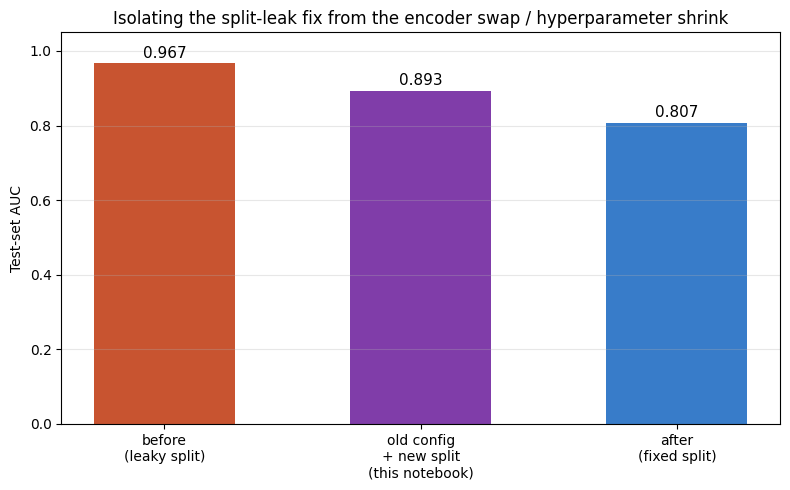

This run vs 'before' (leaky split):  -0.0738
This run vs 'after'  (new encoder+config): +0.0857


In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
names = ["before\n(leaky split)", "old config\n+ new split\n(this notebook)", "after\n(fixed split)"]
values = [BEFORE["test_auc"], TEST_METRICS["auc"], AFTER["test_auc"]]
colors = ["#BF360C", "#6A1B9A", "#1565C0"]

bars = ax.bar(names, values, color=colors, alpha=0.85, width=0.55)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.015, f"{v:.3f}", ha="center", fontsize=11)

ax.set_ylabel("Test-set AUC")
ax.set_ylim(0, 1.05)
ax.set_title("Isolating the split-leak fix from the encoder swap / hyperparameter shrink")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

gap_to_before = TEST_METRICS["auc"] - BEFORE["test_auc"]
gap_to_after = TEST_METRICS["auc"] - AFTER["test_auc"]
print(f"This run vs 'before' (leaky split):  {gap_to_before:+.4f}")
print(f"This run vs 'after'  (new encoder+config): {gap_to_after:+.4f}")

## Interpretation

- If this notebook's AUC lands **close to "before"** (0.94-0.97): the split-leak fix
  by itself does **not** explain the drop — the encoder swap and/or the downstream
  hyperparameter shrink (lstm_hidden 128->32, lstm_layers 2->1, classifier_hidden
  64->32, added standardize_features/weight_decay) are the dominant cause.
- If this notebook's AUC drops **close to "after"** (~0.80): the val-side split leak
  (69/106 GEC-val subjects were in GAAE-train under the legacy split) was materially
  inflating the "before" number, and fixing it accounts for most of the gap on its
  own.
- A result **in between** means the confounds are genuinely entangled and no single
  factor dominates — consistent with `gaae-downstream-leakage-investigation.md`'s own
  caution against attributing the full 0.967->0.807 gap to any one cause.

This is still not a complete decomposition (it holds the encoder *and* hyperparameters
fixed together, varying only the split) — a full ablation would also need "new encoder
+ old config + old split" and "old encoder + new config + new split" arms. But it
directly answers the question this notebook was built to answer: whether the
split-leak fix alone accounts for the observed AUC drop.